Exercício 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

media = 2
var = 3
numero_amostras = 100

X = np.random.normal(media,var,size = numero_amostras)
x = np.linspace(media-10,media+10,500)
pdf = (1/(var*np.sqrt(2*np.pi)))*np.exp(-((x-media)**2/(2*var**2)))

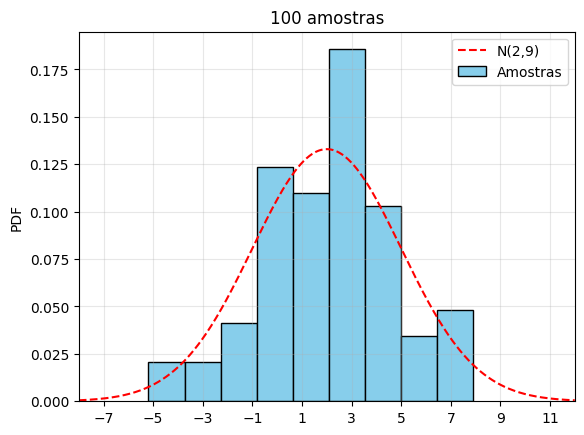

Média teórica = 2
Variância teórica = 3

Média amostral = 2.05415 - Erro base = 2.71%
Variância amostral = 2.70992 - Erro base = 9.67%

Método dos momentos - Média estimada = 2.05415 - Erro = 2.71%
Método dos momentos - Variância estimada = 2.70992 - Erro = 9.67%

Método da verossimilhança - Média estimada = 2.05411 - Erro = 2.71%
Método da verossimilhança - Variância estimada = 2.70942 - Erro = 9.69%


In [2]:
plt.figure()
plt.title(f'{numero_amostras} amostras')
plt.plot(x,pdf,ls='--',color='red',label=f'N({media:d},{var**2:d})')
plt.grid(alpha=0.3)
plt.hist(X,density=True,bins='auto',edgecolor='black',color='skyblue',label='Amostras')
plt.ylabel('PDF')
plt.xlim(media-10,media+10)
plt.legend()
plt.xticks(np.arange(media-9,media+10,2))
plt.show()

print(f'Média teórica = {media:d}')
print(f'Variância teórica = {var:d}\n')
print(f'Média amostral = {np.mean(X):.5f} - Erro base = {(np.abs(np.mean(X)-media)/media)*100:.2f}%')
print(f'Variância amostral = {np.var(X)**.5:.5f} - Erro base = {(np.abs(np.var(X)**.5-var)/var)*100:.2f}%')

#Método dos Momentos
m1 = np.mean(X)
m2 = np.mean((X**2))

def F(theta):
    mu, b = theta
    return [mu - m1,mu**2 + b - m2]

sol = root(F, [1, 2])
mu_hat, b_hat = sol.x

print(f'\nMétodo dos momentos - Média estimada = {mu_hat:.5f} - Erro = {(np.abs(mu_hat-media)/media)*100:.2f}%')
print(f'Método dos momentos - Variância estimada = {b_hat**0.5:.5f} - Erro = {(np.abs(b_hat**.5-var)/var)*100:.2f}%\n')

#Método da Verossimilhança
sigmas = np.linspace(2,4,500)
medias = np.linspace(1,3,500)
L = np.zeros((len(sigmas),len(medias)))
for l in range(len(medias)):
    for j in range(len(sigmas)):
        L[j][l] = - np.log((np.sqrt(2*np.pi)*sigmas[j]))*len(X) - np.sum(np.abs((X-medias[l])**2)) / (2*sigmas[j]**2)

theta_max = np.unravel_index(np.argmax(L), L.shape)
Var = sigmas[theta_max[0]]
med = medias[theta_max[1]]

print(f'Método da verossimilhança - Média estimada = {med:.5f} - Erro = {(np.abs(med-media)/media)*100:.2f}%')
print(f'Método da verossimilhança - Variância estimada = {Var:.5f} - Erro = {(np.abs(Var-var)/var)*100:.2f}%')